# 基本数据结构——张量Tensor

## 【章节目标】
- 掌握创建Tensor的方法
- 掌握Tensor索引的方法
- 掌握Tesnor维度变换方法

## 【章节内容】

### Tensor创建
#### 1）constant()方法
功能：创建一个常量张量，其值不能改变

tf.constant(data,dtype)

- data：张量的数据，标量或者列表

- dtype：指定张量的类型

    - tf.int32
    - tf.int64
    - tf.float32
    - tf.double
    - tf.bool
    - tf.string

In [2]:
import numpy as np
import tensorflow as tf

i = tf.constant(1) # 默认tf.int32 类型常量
l = tf.constant([1, 2, 3, 4], dtype = tf.int64)
f = tf.constant(1.23) # tf.float32
d = tf.constant([[3.14, 2.5], [-1.2, 0.5]], dtype = tf.double)
s = tf.constant("hello world") # tf.string
b = tf.constant(True)

print(i, tf.rank(i))
print(l, tf.rank(l))
print(f)
print(d, tf.rank(d))
print(s)
print(b)

tf.Tensor(1, shape=(), dtype=int32) tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor([1 2 3 4], shape=(4,), dtype=int64) tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(1.23, shape=(), dtype=float32)
tf.Tensor(
[[ 3.14  2.5 ]
 [-1.2   0.5 ]], shape=(2, 2), dtype=float64) tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(b'hello world', shape=(), dtype=string)
tf.Tensor(True, shape=(), dtype=bool)


2026-04-03 02:40:25.238943: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


#### 2）convert_to_tensor()方法
tf.convert_to_tensor(data,dtype)

- data：张量的数据，标量或者列表

- dtype：指定张量的类型

In [3]:
tf.convert_to_tensor(np.ones([2, 3]))

<tf.Tensor: shape=(2, 3), dtype=float64, numpy=
array([[1., 1., 1.],
       [1., 1., 1.]])>

In [4]:
tf.convert_to_tensor(np.ones([2, 3]), dtype = tf.float32)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

#### 3）创建元素为指定值的tensor
熟悉numpy创建数组的方法，一定见过zeros()、ones()等方法，TensorFlow中也有这些方法。

- zeros()与ones()

- zeros_like()与ones_like()

- linspace()和range()

- fill()

In [5]:
tf.zeros([2, 3, 3])

<tf.Tensor: shape=(2, 3, 3), dtype=float32, numpy=
array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)>

In [6]:
a = tf.ones([2,3])
a

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [7]:
tf.zeros_like(a)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>

In [8]:
tf.ones_like(a)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [9]:
tf.linspace(1, 10, 10)

<tf.Tensor: shape=(10,), dtype=float64, numpy=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])>

In [10]:
tf.range(1, 10)

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>

In [11]:
tf.fill([2,3], 5)

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[5, 5, 5],
       [5, 5, 5]], dtype=int32)>

#### 4）随机初始化
在实际应用中，经常需要随机初始化元素服从某种分布的tensor，TensorFlow中也提供了这种功能。

- 从指定正态分布中随机取值：tf.random.normal()

- **从指定的截断正态分布中随机取值：truncated_normal() 意思是从指定的正太分布中取值，但是取值范围在两个标准差范围内，也就是：[ mean - 2 * stddev, mean + 2 * stddev ]**

- 从指定均匀分布中随机取值：tf.random.uniform()

In [13]:
# 随机初始化一个元素服从均值为1，方差为1的正态分布且形状为[2, 3]的tensor：
tf.random.normal([2, 3], mean = 1, stddev = 1)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 2.3042462 ,  1.2448233 , -0.48156023],
       [ 2.3495173 ,  1.6808624 ,  0.9788343 ]], dtype=float32)>

In [14]:
#[ mean - 2 * stddev, mean + 2 * stddev ]
tf.random.truncated_normal([2, 3], mean = 1, stddev = 1)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1.6246035 , 2.7353656 , 0.95972294],
       [1.0098011 , 0.85573566, 1.9022632 ]], dtype=float32)>

In [15]:
tf.random.uniform([2, 3], minval = 1, maxval = 2) # 随机创建1~2之间均匀分布数组

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1.385674 , 1.0810293, 1.3567249],
       [1.9080689, 1.613198 , 1.9184362]], dtype=float32)>

### Tensor索引
#### 1）基础索引
- TensorFlow支持Python原生的基础索引方式，即多个方括号逐步索引取值：[idx][idx][idx]，每个方括号对应一个维度。

- 这种索引数据的方法简单，易于理解，但是可读性差。

In [16]:
# 创建一个4维Tensor
a = tf.convert_to_tensor(np.arange(80).reshape(2,2,4,5))
a

<tf.Tensor: shape=(2, 2, 4, 5), dtype=int64, numpy=
array([[[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9],
         [10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]],

        [[20, 21, 22, 23, 24],
         [25, 26, 27, 28, 29],
         [30, 31, 32, 33, 34],
         [35, 36, 37, 38, 39]]],


       [[[40, 41, 42, 43, 44],
         [45, 46, 47, 48, 49],
         [50, 51, 52, 53, 54],
         [55, 56, 57, 58, 59]],

        [[60, 61, 62, 63, 64],
         [65, 66, 67, 68, 69],
         [70, 71, 72, 73, 74],
         [75, 76, 77, 78, 79]]]])>

In [17]:
a[0]

<tf.Tensor: shape=(2, 4, 5), dtype=int64, numpy=
array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]],

       [[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39]]])>

In [20]:
a[0][1]

<tf.Tensor: shape=(4, 5), dtype=int64, numpy=
array([[20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39]])>

In [21]:
a[0][1][3][3]

<tf.Tensor: shape=(), dtype=int64, numpy=38>

#### 2）numpy索引
TensorFlow也继承了numpy中的部分索引方式

- 索引：[idx1, idx2, idx3]，这种索引方式是在一个方括号内写下所有的索引，每个索引序号之间用逗号隔开。

- 切片：冒号切片与步长：[start:end:step]

In [23]:
a[1, 1, 3] # 0轴取下标为1的元素块、1轴取下标为1的元素块、2轴取下标为3的元素块，3轴元素全选

<tf.Tensor: shape=(5,), dtype=int64, numpy=array([75, 76, 77, 78, 79])>

In [24]:
a[1, :, 0:2] # 0轴取下标为1的元素块，1轴取所有元素块，2轴取下标0到下标1的元素块，3轴元素全选

<tf.Tensor: shape=(2, 2, 5), dtype=int64, numpy=
array([[[40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49]],

       [[60, 61, 62, 63, 64],
        [65, 66, 67, 68, 69]]])>

In [26]:
a[1, :, 0:2, 0:4] # 继续上面的例子，3轴筛选出前4列

<tf.Tensor: shape=(2, 2, 4), dtype=int64, numpy=
array([[[40, 41, 42, 43],
        [45, 46, 47, 48]],

       [[60, 61, 62, 63],
        [65, 66, 67, 68]]])>

In [27]:
a[1, :, 0:2, 0:4:2] # 对3轴加上步长，每隔一个元素取一次

<tf.Tensor: shape=(2, 2, 2), dtype=int64, numpy=
array([[[40, 42],
        [45, 47]],

       [[60, 62],
        [65, 67]]])>

使用负值步长逆序索引，需要注意的是，负数步长时，原本的[start : end : step]也要跟着编程[end : start : step]

In [28]:
a[1, :, 0:2, 4:0:-1]

<tf.Tensor: shape=(2, 2, 4), dtype=int64, numpy=
array([[[44, 43, 42, 41],
        [49, 48, 47, 46]],

       [[64, 63, 62, 61],
        [69, 68, 67, 66]]])>

在numpy和TensorFlow中还有“..."（三个英文句号）的使用，“..."用于表示连续多个维度全选

In [29]:
a[1, ..., 0:4] # 等同于a[1, : , : ,0:4]

<tf.Tensor: shape=(2, 4, 4), dtype=int64, numpy=
array([[[40, 41, 42, 43],
        [45, 46, 47, 48],
        [50, 51, 52, 53],
        [55, 56, 57, 58]],

       [[60, 61, 62, 63],
        [65, 66, 67, 68],
        [70, 71, 72, 73],
        [75, 76, 77, 78]]])>

#### 3）gather与gather_nd
- gather与gather_nd是指TensorFlow通过gather()方法和gather_nd()方法提供的两种索引方式

- 在numpy中，可以通过嵌套list的方式来指定无规则的索引

In [31]:
b = np.arange(20).reshape(4, 5)
b

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [33]:
b[1, [0, 3, 4]] # 选取第2行的第1列、第4列、第5列

array([5, 8, 9])

但是在TensorFlow中，这种索引方式并没有从numpy中继承下来,所以如果在Tensor中使用这种方式，会抛出以下异常：

TypeError: Only integers, slices (:), ellipsis (...), tf.newaxis (None) and scalar tf.int32/tf.int64 tensors are valid indices, got [0, 3, 4]

In [39]:
a = tf.convert_to_tensor(np.arange(20).reshape(4,5))
# a[1, [0,3,4]]

**gather()方法**

tf.gather(tensor, axis, indices)

- tesnor：需要索引的tensor对象

- axis：索引的轴下标

- indices：索引列表

In [38]:
tf.gather(a, axis = 0, indices = [0, 2, 3])

<tf.Tensor: shape=(3, 5), dtype=int64, numpy=
array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])>

In [40]:
tf.gather(a, axis = 1, indices = [0, 2, 3])

<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
array([[ 0,  2,  3],
       [ 5,  7,  8],
       [10, 12, 13],
       [15, 17, 18]])>

**gather_nd()**

gather()方法一次只能对一个维度进行索引，gather_nd()方法可以同时对多个维度进行索引。

tf.gather_nd(tensor,indices)

- tesnor：需要索引的tensor对象

- indices：多维索引列表

In [41]:
tf.gather_nd(a, [[0, 2], [3, 3]]) # 选取第1行第3列的那个数据，和第4行第4列的数据

<tf.Tensor: shape=(2,), dtype=int64, numpy=array([ 2, 18])>

#### 4） 条件索引
- a>10：返回相同shape的bool类型tensor，称之为mask

- tf.boolean_mask(a,mask):取出mask为True的位置对应的元素

- a[a>10]：效果同上

- tf.where(mask)：提取mask为True的位置对应的各维度下标

- tf.where(condition,a,b)：if函数的Tensor版本，返回condition为True，返回a对应位置元素；为False，返回b对应位置元素

In [42]:
a

<tf.Tensor: shape=(4, 5), dtype=int64, numpy=
array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])>

In [44]:
a > 10 # 返回的是一个shape与a相同的tensor，在a大于10的位置是True，小于10的位置为False

<tf.Tensor: shape=(4, 5), dtype=bool, numpy=
array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])>

In [45]:
a[a > 10] # 返回True对应位置的元素，是一个一维Tensor

<tf.Tensor: shape=(9,), dtype=int64, numpy=array([11, 12, 13, 14, 15, 16, 17, 18, 19])>

In [47]:
mask = a > 10
tf.boolean_mask(a, mask) #功能同a[a > 10]

<tf.Tensor: shape=(9,), dtype=int64, numpy=array([11, 12, 13, 14, 15, 16, 17, 18, 19])>

In [49]:
tf.where(a > 10) # 返回大于10的元素各维度的下标

<tf.Tensor: shape=(9, 2), dtype=int64, numpy=
array([[2, 1],
       [2, 2],
       [2, 3],
       [2, 4],
       [3, 0],
       [3, 1],
       [3, 2],
       [3, 3],
       [3, 4]])>

In [51]:
a_index = tf.where(a > 10)
tf.gather_nd(a, a_index)

<tf.Tensor: shape=(9,), dtype=int64, numpy=array([11, 12, 13, 14, 15, 16, 17, 18, 19])>

如果想a>10的位置返回1，否则返回0？怎么办？

In [52]:
# 构造同shape的全0和全1的tensor, 可以使用广播机制
ones_a = tf.ones_like(a)
zeros_a = tf.zeros_like(a)
ones_a, zeros_a

(<tf.Tensor: shape=(4, 5), dtype=int64, numpy=
 array([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]])>,
 <tf.Tensor: shape=(4, 5), dtype=int64, numpy=
 array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])>)

In [54]:
# tf.where(a>10, ones_a, zeros_a)
tf.where(a>10,1,0)

<tf.Tensor: shape=(4, 5), dtype=int32, numpy=
array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=int32)>

#### 5）张量刷新scatter_nd
通过 tf.scatter_nd(indices, updates, shape)可以高效地刷新张量的部分数据，但是只能在全 0 张量的白板上面刷新，因此可能需要结合其他操作来实现现有张量的数据刷新功能。

如下图所示，演示了一维张量白板的刷新运算，白板的形状表示为 shape 参数，需要刷新的数据索引为 indices，新数据为 updates，其中每个需要刷新的数据对应在白板中的位置，根据 indices 给出的索引位置将 updates 中新的数据依次写入白板中，并返回更新后的白板张量。

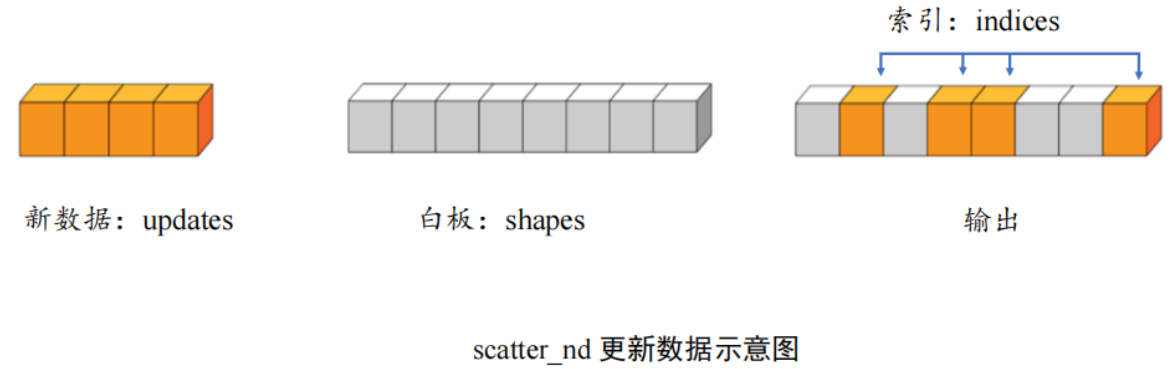

In [56]:
# 构造需要刷新数据的位置
indices = tf.constant([[4], [3], [1], [7]])
# 构造需要写入的数据
updates = tf.constant([4.4, 3.3, 1.1, 7.7]) 
# 在长度为 8 的全 0 向量上根据 indices 写入 updates
tf.scatter_nd(indices, updates, [8]) # 可以看到，在长度为 8 的白板上，写入了对应位置的数据，一个 4 个新数据被刷新

<tf.Tensor: shape=(8,), dtype=float32, numpy=array([0. , 1.1, 0. , 3.3, 4.4, 0. , 0. , 7.7], dtype=float32)>

考虑 3 维张量的刷新例子，如下图所示，白板 shape 为[4,4,4]，共有 4 个通道的特征图，现有需 2 个通道的新数据 updates:[2,4,4]，需要写入索引为[1,3]的通道上：

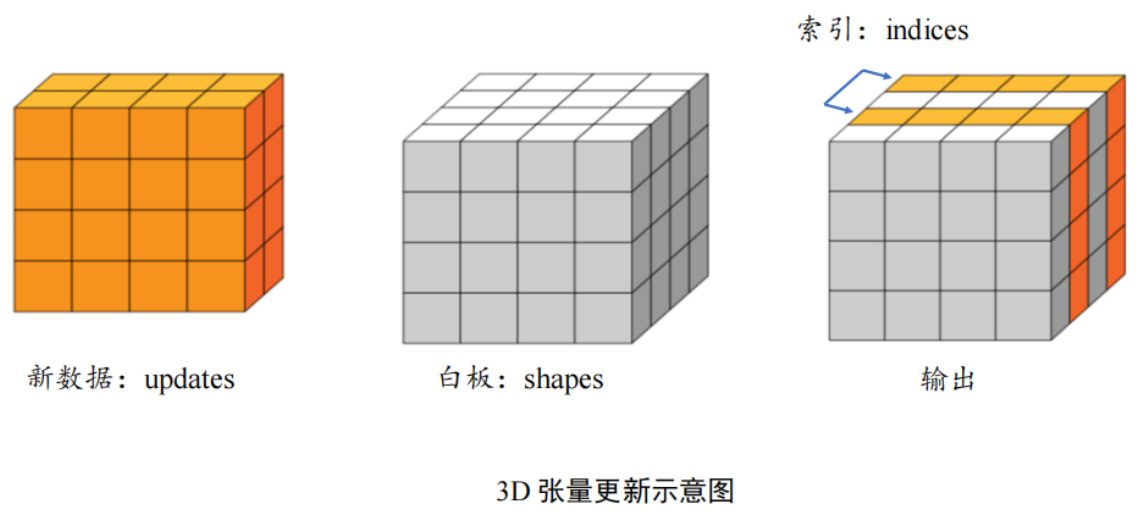

将新的特征图写入现有白板张量，实现如下：

In [57]:
# 构造写入位置
indices = tf.constant([[1], [3]])
updates = tf.constant([# 构造写入数据
 [[5,5,5,5],[6,6,6,6],[7,7,7,7],[8,8,8,8]],
 [[1,1,1,1],[2,2,2,2],[3,3,3,3],[4,4,4,4]]
])
# 在 shape 为[4,4,4]白板上根据 indices 写入 updates
tf.scatter_nd(indices, updates, [4,4,4]) #可以看到，数据被刷新到第 2,4 个通道特征图上

<tf.Tensor: shape=(4, 4, 4), dtype=int32, numpy=
array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[5, 5, 5, 5],
        [6, 6, 6, 6],
        [7, 7, 7, 7],
        [8, 8, 8, 8]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3],
        [4, 4, 4, 4]]], dtype=int32)>

### 维度变换
#### 1）reshape()
numpy中的ndarray数组有个一reshape()方法，用来改变数组的shape，TensorFlow中的reshape()方法，功能也是一样的，不过TensorFlow中的reshape()没有绑定到tensor中

**tf.reshape(a,new_shape)** 而不能 a.reshape(new_shape)

In [59]:
import tensorflow as tf
a = tf.ones([2, 3, 4])
a.shape

TensorShape([2, 3, 4])

In [60]:
b = tf.reshape(a, [2, 2, 6])
b.shape

TensorShape([2, 2, 6])

In [62]:
tf.reshape(a, [2, 2, 6]) #元素个数必须相等

<tf.Tensor: shape=(2, 2, 6), dtype=float32, numpy=
array([[[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]]], dtype=float32)>

#### 2）转置：transpose()
功能：交换轴顺序

tf.transpose(tensor,perm)

- perm：指定新的轴顺序，默认逆序

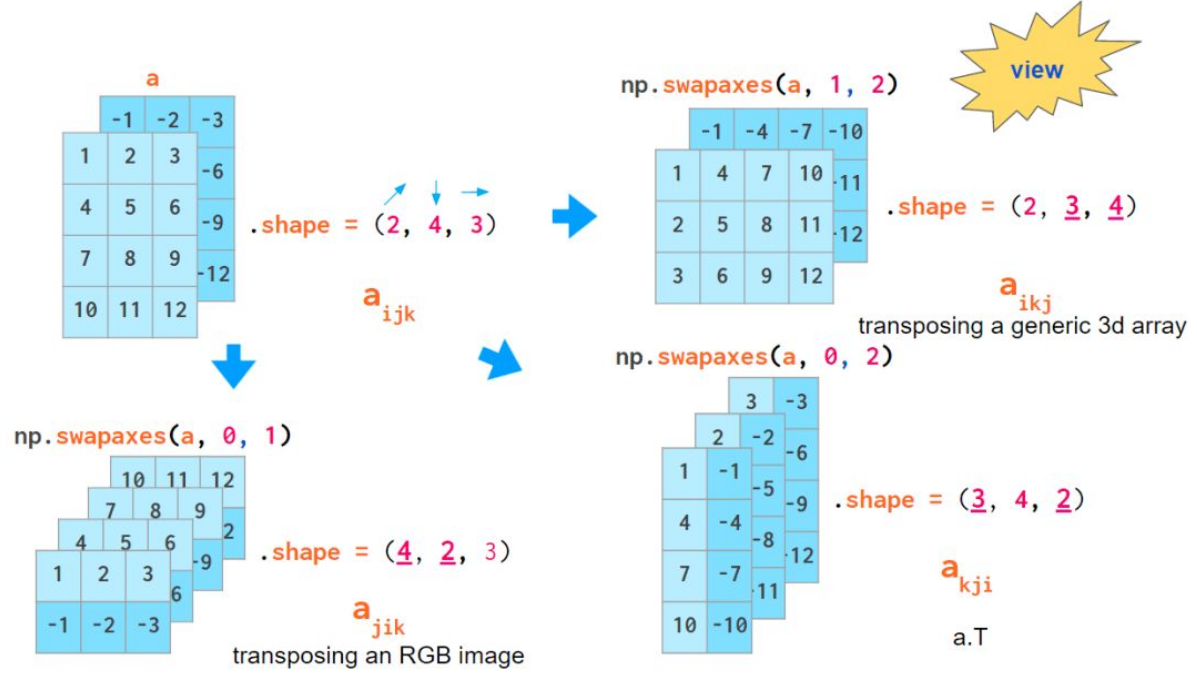

In [63]:
import numpy as np

a = tf.convert_to_tensor(np.arange(24).reshape(2, 3, 4))
a

<tf.Tensor: shape=(2, 3, 4), dtype=int64, numpy=
array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])>

In [64]:
tf.transpose(a)

<tf.Tensor: shape=(4, 3, 2), dtype=int64, numpy=
array([[[ 0, 12],
        [ 4, 16],
        [ 8, 20]],

       [[ 1, 13],
        [ 5, 17],
        [ 9, 21]],

       [[ 2, 14],
        [ 6, 18],
        [10, 22]],

       [[ 3, 15],
        [ 7, 19],
        [11, 23]]])>

In [65]:
tf.transpose(a, perm = [2, 0, 1])

<tf.Tensor: shape=(4, 2, 3), dtype=int64, numpy=
array([[[ 0,  4,  8],
        [12, 16, 20]],

       [[ 1,  5,  9],
        [13, 17, 21]],

       [[ 2,  6, 10],
        [14, 18, 22]],

       [[ 3,  7, 11],
        [15, 19, 23]]])>

#### 3）添加维度：expand_dims()
tf.expand_dims(a, axis=-1)

- 功能：给a增加一个指定下标（axis）的轴（维度），且该轴的长度为1。总元素个数不变

- axis：必须，添加维度的轴下标

In [66]:
a = tf.constant([[1, 2, 3], [4, 5, 6]])
a.shape

TensorShape([2, 3])

In [67]:
tf.expand_dims(a, axis = 0)

<tf.Tensor: shape=(1, 2, 3), dtype=int32, numpy=
array([[[1, 2, 3],
        [4, 5, 6]]], dtype=int32)>

In [68]:
tf.expand_dims(a, axis = 1)

<tf.Tensor: shape=(2, 1, 3), dtype=int32, numpy=
array([[[1, 2, 3]],

       [[4, 5, 6]]], dtype=int32)>

In [69]:
tf.expand_dims(a, axis = 2)

<tf.Tensor: shape=(2, 3, 1), dtype=int32, numpy=
array([[[1],
        [2],
        [3]],

       [[4],
        [5],
        [6]]], dtype=int32)>

#### 4）压缩维度：squeeze()
squeeze()方法与expand_dims()方法作用刚好相反，其作用是删除张量中长度为1的维度

**tf.squeeze(a,axis)**

- axis：指定要消除dim的轴下标，只有指定轴的长度为1才有效,否则报错

- 不指定axis降删除所有长度为1的轴

In [70]:
a = tf.ones([1, 3 , 1, 2])
a.shape

TensorShape([1, 3, 1, 2])

In [71]:
tf.squeeze(a).shape

TensorShape([3, 2])

In [72]:
tf.squeeze(a, axis = 0).shape

TensorShape([3, 1, 2])

In [74]:
# tf.squeeze(a, axis = 1).shape # Can not squeeze dim[1]